In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings

%matplotlib inline

2025-03-19 11:39:10.698360: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-19 11:39:10.869399: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# HOME = "/scistor/ivm/the410/"

HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *

In [4]:
pwd

'/gpfs/home4/thappe/HeaT'

In [5]:
### GLOBAL VARIABLES IVM

os.chdir(HOME)

#IVM 
# data_path = "/scistor/ivm/the410/PAPER3"

#SNELLIUS
data_path = "/home/thappe/data/VAE_MODEL"

In [6]:
ls /home/thappe/data/VAE_MODEL

ERA5_t2m_dynamic_encoded_heatwaves_L128.csv
ERA5_t2m_dynamic_heatwaves_dates.csv
ERA5_t2m_encoded_heatwaves_L128.csv
ERA5_t2m_heatwaves_dates.csv
ERA5_t2m_minus_thermo_encoded_heatwaves_L128.csv
ERA5_t2m_minus_thermo_heatwaves_dates.csv
GMM.pkl
Kmeanseucl.pkl
VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5


## LOADING DATA 

In [7]:
t2m_name = "t2m_minus_thermo" 

assert t2m_name in ["t2m", "t2m_dynamic", "t2m_minus_thermo"], "data not available for this var"

VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5")

In [26]:
##load heatwave means from csv and datetime information 

heatwave_means = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_encoded_heatwaves_L{VAE_model[0]}.csv', 
                             skiprows=1, header=None)

heatwave_dates = pd.read_csv(f'{data_path}/ERA5_{t2m_name}_heatwaves_dates.csv',
                             skiprows=1, header=None)
#convert into dates from datetime 
heatwave_dates[0] = pd.to_datetime(heatwave_dates[0]).dt.date
dates = heatwave_dates.values.flatten()

In [9]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

### bij welk cluster horen de heatwaves?

In [37]:
heatwave_means.values.shape

(739, 128)

In [35]:
import sklearn

In [36]:
print('The scikit-learn version is {}.'.format(sklearn.__version__))

The scikit-learn version is 1.2.2.


In [120]:
pip install scikit-learn==1.2.2

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 106.1 MB/s eta 0:00:0000:010:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2
You should consider upgrading via the '/sw/arch/RHEL8/EB_production/2022/software/Python/3.10.4-GCCcore-11.3.0/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [50]:
## load kmeans / GMM 

import pickle
import scipy


to_cluster = heatwave_means.values

## to open the GM model
f=f'{data_path}/GMM.pkl'
GM = pickle.load(open(f, 'rb'))

## predict heatwave clusters 
y_pred_GM = GM.predict(to_cluster)

# y_pred_GM = GM.fit_predict(to_cluster) ## transfer learning--> will result in slighly different results each time

#to get individual probabilities of belonging to cluster
probs = GM.predict_proba(to_cluster)

#to get the centers
GM_centers = np.empty(shape=(GM.n_components, to_cluster.shape[1]))
for i in range(GM.n_components):
    density = scipy.stats.multivariate_normal(cov=GM.covariances_[i], mean=GM.means_[i]).logpdf(to_cluster)
    GM_centers[i, :] = to_cluster[np.argmax(density)]

In [41]:
## TSNE space? 

## clusters over time

In [42]:
## plotting over time

In [51]:
## initialize empty dictionary 
year_counts = {}
for year in np.arange(1940, 2024, 1):
    year_counts[year] = {1:0, 2:0, 3:0, 4:0}
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts[date.year][cluster_id] += 1 #add one to this year and cluster count

In [52]:
year_counts_reversed = {}
for cluster_id in [1,2,3,4]:
    cluster_ids = {}
    for year in np.arange(1940, 2024, 1):
        cluster_ids[year] = 0
    year_counts_reversed[cluster_id] = cluster_ids

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_reversed[cluster_id][date.year] += 1 #add one to this year and cluster count
    

In [53]:
year_counts_for_plotting = {}

for year in np.arange(1940, 2024, 1):
    year_counts_for_plotting[year] = [0,0,0,0]

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_counts_for_plotting[date.year][cluster] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting

In [54]:
years = np.arange(1940, 2024, 1)
year_counts_for_plotting_reversed  = {}


for cluster_id in [1,2,3,4]:
    year_counts_for_plotting_reversed[cluster_id] = np.zeros_like(years)
    

for date, cluster in zip(dates, y_pred_GM):
    cluster_id = cluster+1
    year_index = np.where(years==date.year)
    year_counts_for_plotting_reversed[cluster_id][year_index] += 1 #add one to this year and cluster count
    
# year_counts_for_plotting_reversed

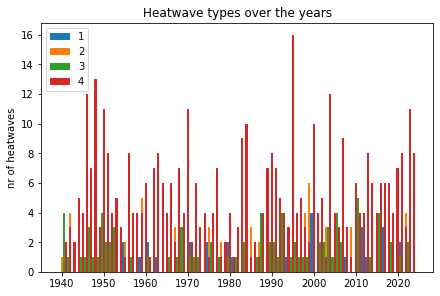

In [55]:
years = np.arange(1940, 2024, 1)

x = np.arange(len(years))  # the label locations
width = 0.5  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=cluster_id)
#     ax.bar_label(rects, padding=3)
    multiplier += 1

# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(len(np.arange(1940,2024,10)))*10 +width, np.arange(1940,2024,10))
ax.legend(loc='upper left') #, ncols=3)

plt.show()

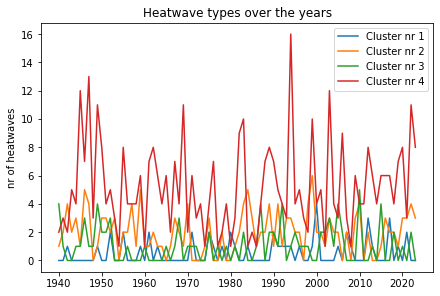

In [56]:
years = np.arange(1940, 2024, 1)

fig, ax = plt.subplots(layout='constrained')

for cluster_id, counts in year_counts_for_plotting_reversed.items():
    ax.plot(years, counts, label=f"Cluster nr {cluster_id}")
    
# # Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('nr of heatwaves')
ax.set_title('Heatwave types over the years')
ax.set_xticks(np.arange(1940,2024,10))
ax.legend(loc='upper right') #, ncols=1)

plt.show()

1
2
3
4


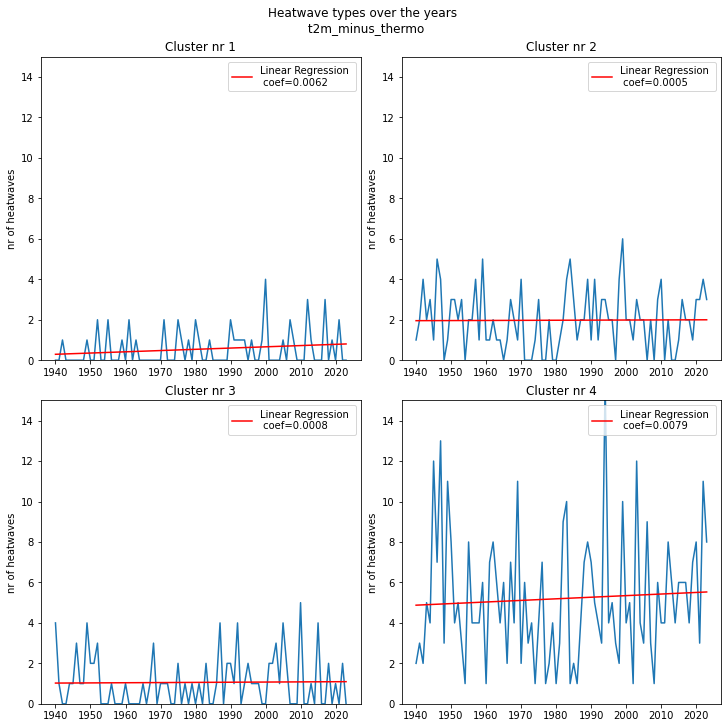

In [57]:
years = np.arange(1940, 2024, 1)

fig, axes = plt.subplots(2,2, figsize=(10,10), layout='constrained')

for cluster_id, ax in zip([1,2,3,4], axes.flatten()):
    print(cluster_id)

    ax.plot(years, year_counts_for_plotting_reversed[cluster_id]) #, label=f"Cluster nr {cluster_id}")

    from sklearn.linear_model import LinearRegression
    reg = LinearRegression().fit(years.reshape(-1, 1), year_counts_for_plotting_reversed[cluster_id])
    Y = reg.predict(years.reshape(-1, 1))
    ax.plot(years, Y, label=f"Linear Regression \n coef={round(reg.coef_[0], 4)}", c="red")

    # # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('nr of heatwaves')
    ax.set_title(f"Cluster nr {cluster_id}")
    ax.set_xticks(np.arange(1940,2024,10))
    ax.legend(loc='upper right') #, ncols=1)
    ax.set_ylim(0,15)
    
fig.suptitle(f'Heatwave types over the years \n {t2m_name}')
plt.show()

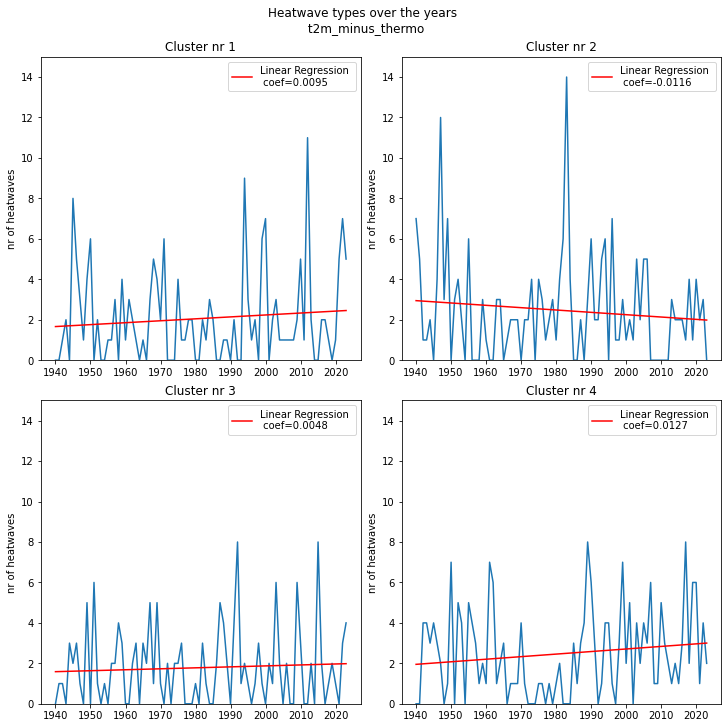